In [ ]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10_sandbox, UR10_weighted, Test1, Test2, Trajectories
from optimal.metrics import thermal_energy, mechanical_work, peak_power, plot_controls_and_error, plot_metrics
import numpy as np

type = UR10_sandbox
params = Test1.PDValues.BayesianOptimization.TPE.Global
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)
# payload = robot_mj_model.get_obj_payload("box_2")
# robot_pin_model.add_payload("wrist_3_link", payload)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_6dof
controller = RobotController(robot_pin_model)
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
start = np.concatenate([path[0], v_start])
for i in range(len(path) - 1):
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT,
                                        kp=params.kp,
                                        kd=params.kd,
                                        alpha=params.alpha,
                                        interpolation=params.interpolation,
                                        option="pd")
    start = np.concatenate([t_xs[-1][:len(robot_pin_model.q_indices)], t_xs[-1][len(robot_pin_model.q_indices):]])
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]

# robot_mj_model.reset()
# xs_real, us_real = robot_mj_model.simulate_control(us=us, xs=xs, kp=type.kp, kd=type.kd)
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", xs, us, DT, kp=type.kp, kd=type.kd, plot=True)
lengths = [1000 for _ in path[1:]]
plot_controls_and_error(us_real, xs_real, DT, path[1:], lengths)
plot_metrics(us_real, xs_real, DT, path[1:], lengths)

AttributeError: type object 'BoxFDDP' has no attribute 'kp'

6000 6000
Joint     Corr FF↔tot  RMS FF %  RMS FB %    MAE FB
-------------------------------------------------------
  1            0.1819     16.2%     98.4%   21.7633
  2            0.8096     93.0%     26.7%   31.7384
  3            0.9059     97.4%     12.7%   10.7438
  4            0.2632     55.8%     91.7%   20.7710
  5            0.8235     75.4%     53.1%    3.5767
  6            0.4456     41.1%     89.6%    0.0199
Global FF coverage: 92.9%   FB correction: 30.0%
Global correlation FF↔tot: 0.9339


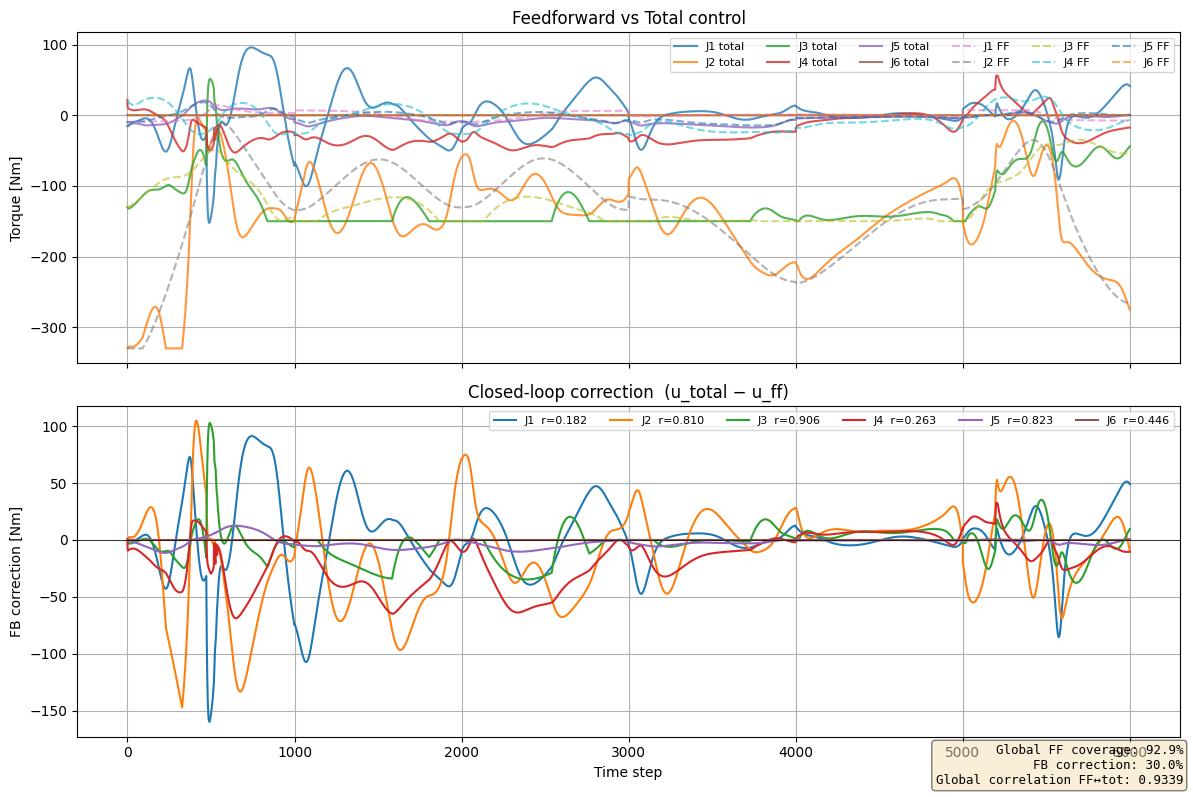

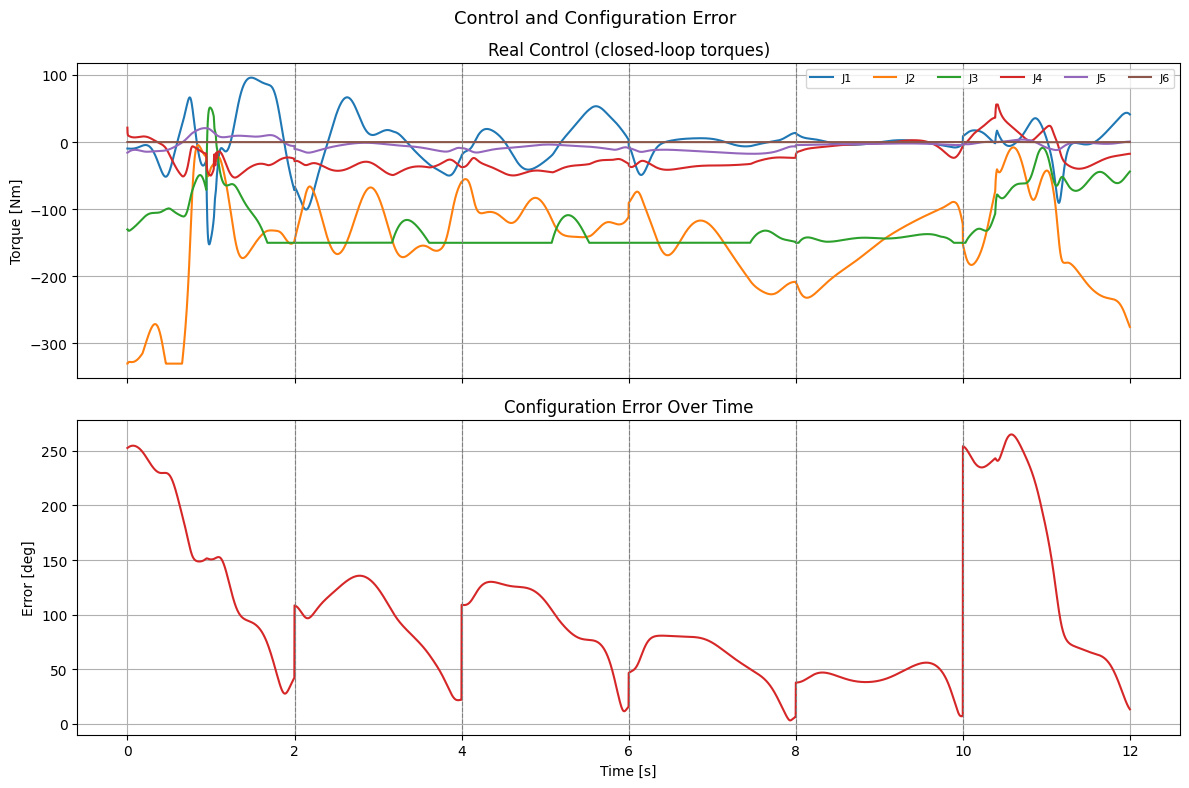

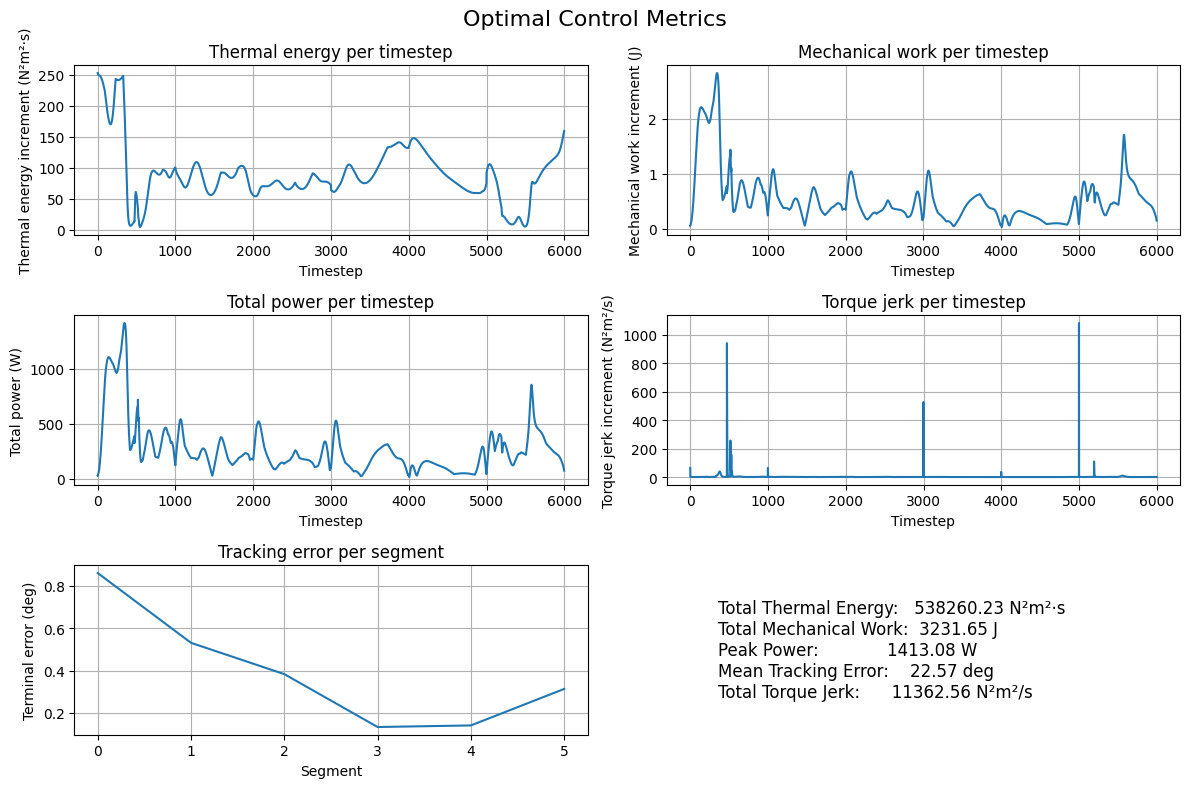

1584329.9300421989

In [3]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10_sandbox, UR10_weighted, Test1, Test2, Trajectories
from optimal.metrics import thermal_energy, mechanical_work, peak_power, plot_controls_and_error, plot_metrics
import numpy as np
import crocoddyl

type = UR10_weighted
# type = UR10_sandbox
params = Test1.CrocoddylValues.BayesianOptimization.TPE.TrackInterp.BoxFDDP
PDparams = Test1.PDValues.BayesianOptimization.TPE.Global
robot_mj_model = RobotMujocoModel(type.mjcf_path, type.list_of_joints)
robot_pin_model = RobotPinocchioModel(type.urdf_path, type.list_of_joints)
controller = RobotController(robot_pin_model)
payload = robot_mj_model.get_obj_payload("box_2")
robot_pin_model.add_payload("robotiq_85_base_link", payload)
controller.update_pin_model(robot_pin_model)

DT = robot_mj_model.model.opt.timestep
path = Trajectories.joint_weighted
xs, us = [], []
v_start = np.zeros(len(robot_pin_model.v_indices))
for i in range(len(path) - 1):
    start = np.concatenate([path[i], v_start])
    target = np.concatenate([path[i+1], np.zeros(len(robot_pin_model.v_indices))])
    t_xs, t_us = controller.compute_control(x_start=start, 
                                        x_goal=target, 
                                        T=1000, DT=DT, 
                                        kp=type.kp, kd=type.kd, 
                                        track_weight=params.track_w,
                                        terminal_pose_weight=params.term_w,
                                        acc_weight=params.acc_w,
                                        ctrl_weight=params.ctrl_w,
                                        terminal_v_weight=params.term_w,
                                        v_weight=params.v_w,
                                        alpha=0.9, interpolation="quintic",
                                        track_interpolated=False,
                                        option="crocoddyl_advanced", solver=crocoddyl.SolverBoxFDDP
                                        )
    xs.extend(t_xs)
    us.extend(t_us)
    v_start = xs[-1][len(robot_pin_model.q_indices):]

print(len(xs), len(us))
robot_mj_model.reset()

# CHANGED: You must run simulate_control to see physics! visualize("position") ignores physics.
# xs_real, us_real = robot_mj_model.visualize("control", us=us, xs=xs, kp=type.kp, kd=type.kd, dt=DT, hold=False, plot=False)
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt =0.002)
# xs_real, us_real = xs, us
# robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", xs, us, DT, kp=type.kp, kd=type.kd, plot=True)
lengths = [1000 for _ in path[1:]]
plot_controls_and_error(us_real, xs_real, DT, path[1:], lengths)
plot_metrics(us_real, xs_real, DT, path[1:], lengths)
from optimal.metrics import summary_metrics, unified_cost
unified_cost(us_real, xs_real, DT, path[1:], lengths)


In [2]:
robot_mj_model.reset()
xs_real, us_real = robot_mj_model.visualize("control", xs, us, DT, kp=type.kp, kd=type.kd, plot=True)
# xs_real, us_real = robot_mj_model.visualize("position", xs=xs, dt =0.001)
robot_mj_model.plot_position(xs_real)

from optimal.metrics import summary_metrics, unified_cost

print("Summary Metrics:")
summary_metrics(us_real, xs_real, DT, path[1:], lengths)
unified_cost(us_real, xs_real, DT, path[1:], lengths)

NameError: name 'robot_mj_model' is not defined